Dataset Loaded Successfully!
<class 'pandas.DataFrame'>
RangeIndex: 101000 entries, 0 to 100999
Data columns (total 18 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Property_ID           101000 non-null  str    
 1   Micro_Market          101000 non-null  str    
 2   Project_Name          101000 non-null  str    
 3   Developer_Name        101000 non-null  str    
 4   Unit_Size_Sqft        90954 non-null   float64
 5   Configuration         101000 non-null  str    
 6   Ticket_Price_Cr       90981 non-null   str    
 7   Transaction_Type      101000 non-null  str    
 8   Buyer_Type            101000 non-null  str    
 9   Purchase_Quarter      101000 non-null  str    
 10  Connectivity_Score    101000 non-null  float64
 11  Amenity_Score         90910 non-null   float64
 12  Possession_Status     101000 non-null  str    
 13  Sales_Channel         101000 non-null  str    
 14  NRI_Buyer             101000 non-n

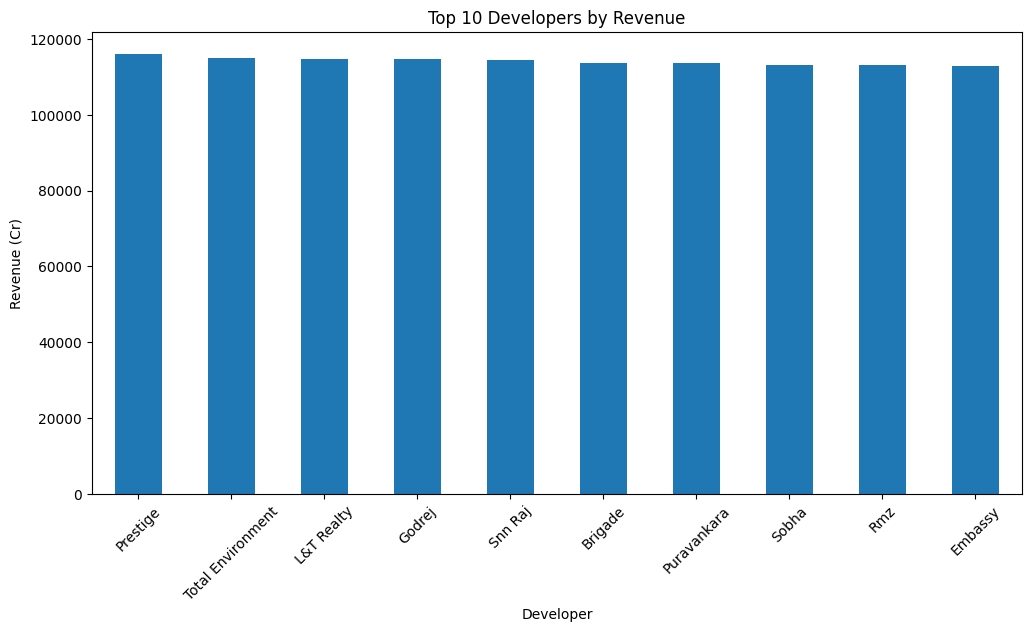

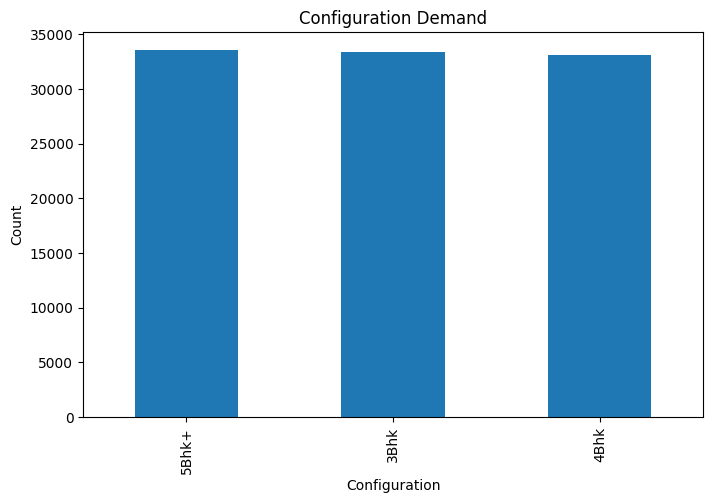

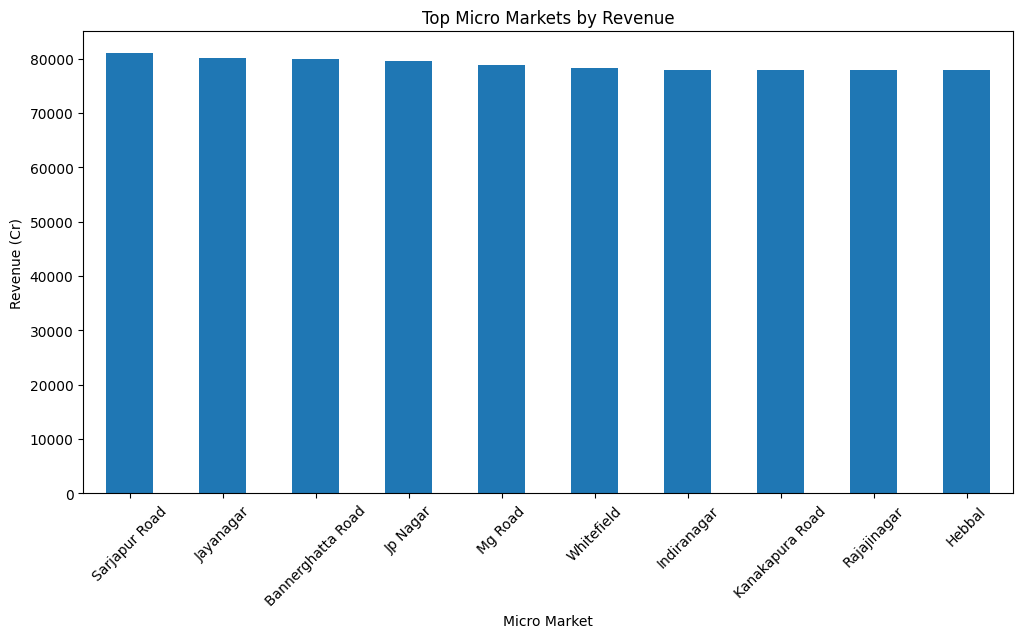

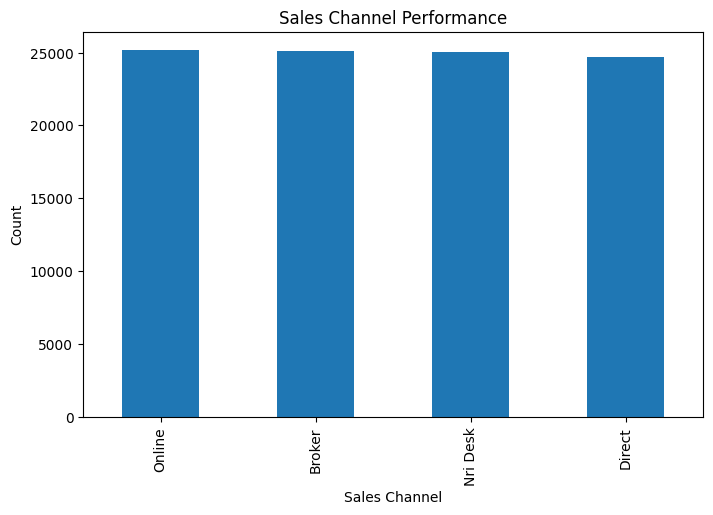

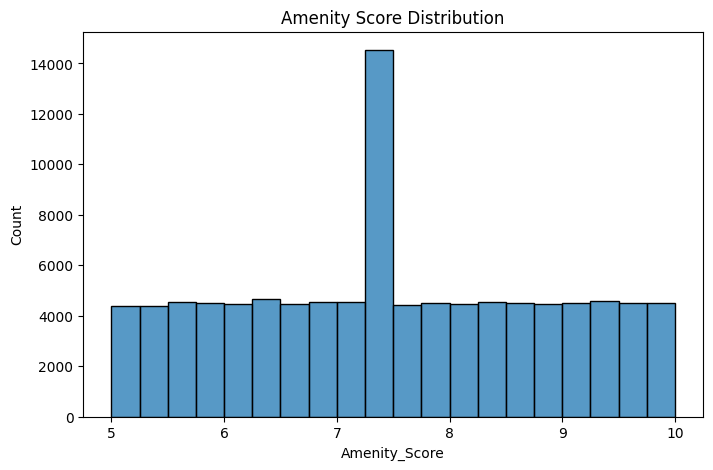

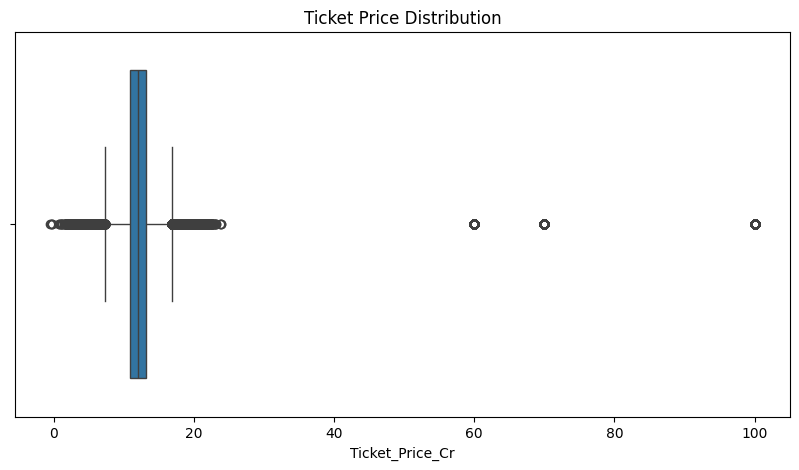

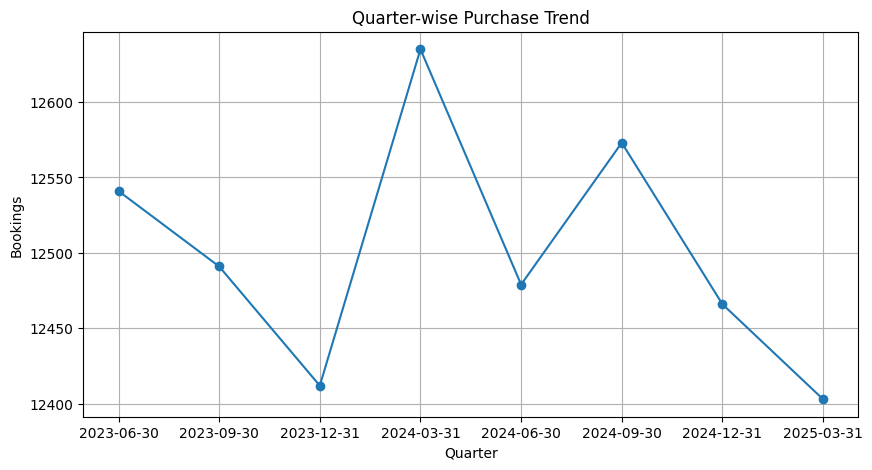

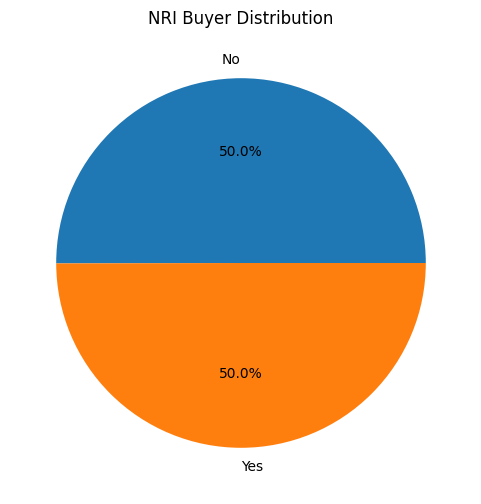

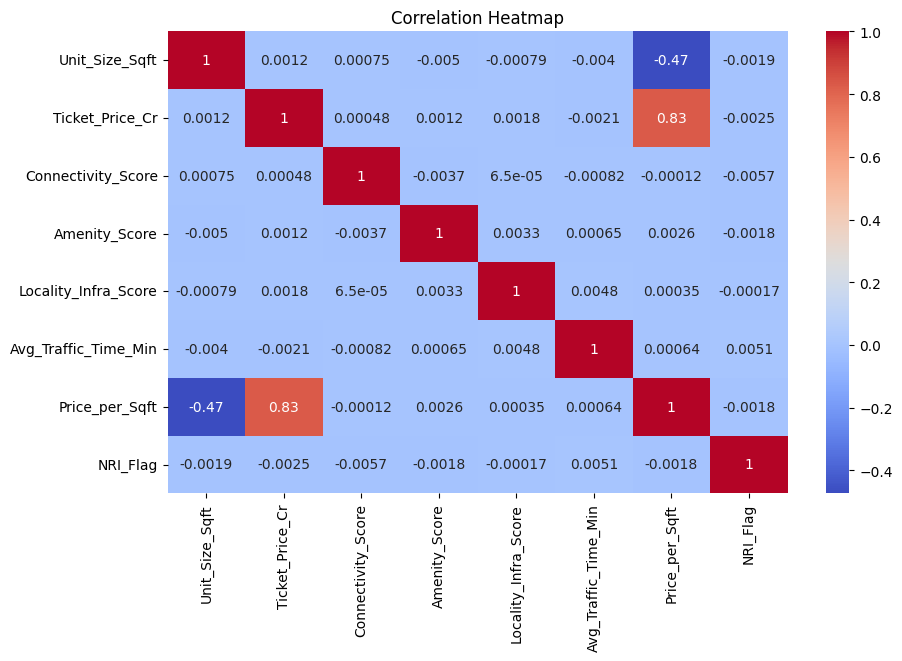

========== BUSINESS INSIGHTS ==========
\nTop Revenue Developer:
Developer_Name
Prestige    116021.664972
Name: Ticket_Price_Cr, dtype: float64
\nMost Demanded Configuration:
Configuration
5Bhk+    33536
Name: count, dtype: int64
\nTop Revenue Micro Market:
Micro_Market
Sarjapur Road    80948.121451
Name: Ticket_Price_Cr, dtype: float64
SQLite database connected successfully!
Dataset uploaded successfully!


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
df = pd.read_csv("C:\\vscode\\luxury_housing_project\\data\\raw\\Luxury_Housing_Bangalore.csv")
print("Dataset Loaded Successfully!")
df.head()
df.shape
df.columns
df.info()
df.isnull().sum()
df.describe()
# ==========================================
# DATA CLEANING
# ==========================================
print("Duplicate Rows:", df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("Duplicates Removed Successfully!")
min = -1
df['Unit_Size_Sqft'] = df['Unit_Size_Sqft'].replace(-1, np.nan)
df['Unit_Size_Sqft'] = df['Unit_Size_Sqft'].fillna(
    df['Unit_Size_Sqft'].median()
)
df['Ticket_Price_Cr'] = (
    df['Ticket_Price_Cr']
    .astype(str)
    .str.replace('Cr', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
)
df['Ticket_Price_Cr'] = pd.to_numeric(
    df['Ticket_Price_Cr'],
    errors='coerce'
)
df['Ticket_Price_Cr'] = df['Ticket_Price_Cr'].fillna(
    df['Ticket_Price_Cr'].median()
)
df['Amenity_Score'] = df['Amenity_Score'].fillna(
    df['Amenity_Score'].median()
)
df['Buyer_Comments'] = df['Buyer_Comments'].fillna(
    "No Comments"
)
text_cols = [
    'Micro_Market',
    'Project_Name',
    'Developer_Name',
    'Configuration',
    'Transaction_Type',
    'Buyer_Type',
    'Possession_Status',
    'Sales_Channel',
    'NRI_Buyer'
]

for col in text_cols:
    df[col] = df[col].str.strip().str.title()

print("Text Standardization Completed!")
df.isnull().sum()
df.info()
# ==========================================
# FEATURE ENGINEERING
# ==========================================
df['Price_per_Sqft'] = (
    (df['Ticket_Price_Cr'] * 10000000)
    / df['Unit_Size_Sqft']
)
print("Price_per_Sqft column created!")
conditions = [
    df['Ticket_Price_Cr'] < 3,
    (df['Ticket_Price_Cr'] >= 3) & (df['Ticket_Price_Cr'] < 7),
    df['Ticket_Price_Cr'] >= 7
]

categories = [
    'Premium',
    'Luxury',
    'Ultra Luxury'
]

df['Property_Category'] = np.select(
    conditions,
    categories,
    default='Luxury'
)

print("Property_Category column created!")
df['Quarter_Number'] = (
    df['Purchase_Quarter']
    .str.extract(r'(\d)')
)

print("Quarter_Number created!")
df['NRI_Flag'] = df['NRI_Buyer'].apply(
    lambda x: 1 if x == 'Yes' else 0
)

print("NRI_Flag created!")
df['Traffic_Category'] = pd.cut(
    df['Avg_Traffic_Time_Min'],
    bins=[0, 30, 60, 90, 120],
    labels=['Low', 'Medium', 'High', 'Very High']
)

print("Traffic_Category created!")
df['Amenity_Category'] = pd.cut(
    df['Amenity_Score'],
    bins=[0, 6, 8, 10],
    labels=['Basic', 'Good', 'Premium']
)

print("Amenity_Category created!")
df.head()
df.shape
df.to_csv(
    "C:\\vscode\\luxury_housing_project\\data\\cleaned\\Luxury_Housing_Cleaned.csv",
    index=False
)
print("Cleaned dataset saved successfully!")
# ==========================================
# EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================
top_developers = (
    df.groupby('Developer_Name')['Ticket_Price_Cr']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

top_developers.plot(kind='bar')

plt.title('Top 10 Developers by Revenue')
plt.xlabel('Developer')
plt.ylabel('Revenue (Cr)')
plt.xticks(rotation=45)

plt.show()
plt.figure(figsize=(8,5))

df['Configuration'].value_counts().plot(kind='bar')

plt.title('Configuration Demand')
plt.xlabel('Configuration')
plt.ylabel('Count')

plt.show()
top_markets = (
    df.groupby('Micro_Market')['Ticket_Price_Cr']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

top_markets.plot(kind='bar')

plt.title('Top Micro Markets by Revenue')
plt.xlabel('Micro Market')
plt.ylabel('Revenue (Cr)')
plt.xticks(rotation=45)

plt.show()
sales_channel = (
    df['Sales_Channel']
    .value_counts()
)

plt.figure(figsize=(8,5))

sales_channel.plot(kind='bar')

plt.title('Sales Channel Performance')
plt.xlabel('Sales Channel')
plt.ylabel('Count')

plt.show()
plt.figure(figsize=(8,5))

sns.histplot(df['Amenity_Score'], bins=20)

plt.title('Amenity Score Distribution')

plt.show()
plt.figure(figsize=(10,5))

sns.boxplot(x=df['Ticket_Price_Cr'])

plt.title('Ticket Price Distribution')

plt.show()
quarter_trend = (
    df['Purchase_Quarter']
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10,5))

quarter_trend.plot(marker='o')

plt.title('Quarter-wise Purchase Trend')
plt.xlabel('Quarter')
plt.ylabel('Bookings')

plt.grid(True)

plt.show()
plt.figure(figsize=(6,6))

df['NRI_Buyer'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('NRI Buyer Distribution')
plt.ylabel('')

plt.show()
numeric_df = df.select_dtypes(include=['float64', 'int64'])

plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()
print("========== BUSINESS INSIGHTS ==========")

# Top Developer
top_dev = (
    df.groupby('Developer_Name')['Ticket_Price_Cr']
    .sum()
    .sort_values(ascending=False)
    .head(1)
)

print("\\nTop Revenue Developer:")
print(top_dev)

# Most Demanded Configuration
top_config = (
    df['Configuration']
    .value_counts()
    .head(1)
)

print("\\nMost Demanded Configuration:")
print(top_config)

# Top Micro Market
top_market = (
    df.groupby('Micro_Market')['Ticket_Price_Cr']
    .sum()
    .sort_values(ascending=False)
    .head(1)
)

print("\\nTop Revenue Micro Market:")
print(top_market)
conn = sqlite3.connect("../sql/luxury_housing.db")

print("SQLite database connected successfully!")
df.to_sql(
    name='housing_sales',
    con=conn,
    if_exists='replace',
    index=False
)

print("Dataset uploaded successfully!")

